# Task 2: Exploratory Data Analysis
Ethiopia Financial Inclusion Forecasting — Selam Analytics

This notebook uses the reusable modules in `src/` (`data_loader`, `eda_analysis`, `visualization`) rather than inline analysis, so the logic here is tested, documented, and reusable in the dashboard (Task 5).

In [1]:
import sys
sys.path.append("..")

from src.data_loader import load_unified_dataset, load_reference_codes, validate_against_reference
from src.eda_analysis import (
    summarize_by, temporal_coverage, sparse_indicators, compute_growth_rates,
    correlation_matrix, registered_vs_active_gap, events_without_impact_links
)
from src.visualization import (
    plot_overview, plot_temporal_coverage, plot_indicator_trend, plot_event_overlay
)

main_df, impact_df = load_unified_dataset("../data/processed/ethiopia_fi_unified_data_enriched.xlsx")
ref_df = load_reference_codes("../data/raw/reference_codes.xlsx")

print("Main sheet:", main_df.shape)
print("Impact sheet:", impact_df.shape)

Main sheet: (47, 34)
Impact sheet: (15, 35)


## Section 1: Dataset Overview

In [2]:
violations = validate_against_reference(main_df, ref_df)
print(f"Schema violations found: {len(violations)}")
if len(violations):
    display(violations)

Schema violations found: 0


In [3]:
print("Records by type:")
print(summarize_by(main_df, "record_type"))

print("\nRecords by pillar (observations + targets only):")
obs_target = main_df[main_df["record_type"].isin(["observation", "target"])]
print(obs_target["pillar"].value_counts())

print("\nConfidence distribution:")
print(summarize_by(main_df, "confidence"))

Records by type:
record_type
observation    34
event          10
target          3
Name: count, dtype: int64

Records by pillar (observations + targets only):
pillar
ACCESS           18
USAGE            12
GENDER            6
AFFORDABILITY     1
Name: count, dtype: int64

Confidence distribution:
confidence
high      40
medium     7
Name: count, dtype: int64


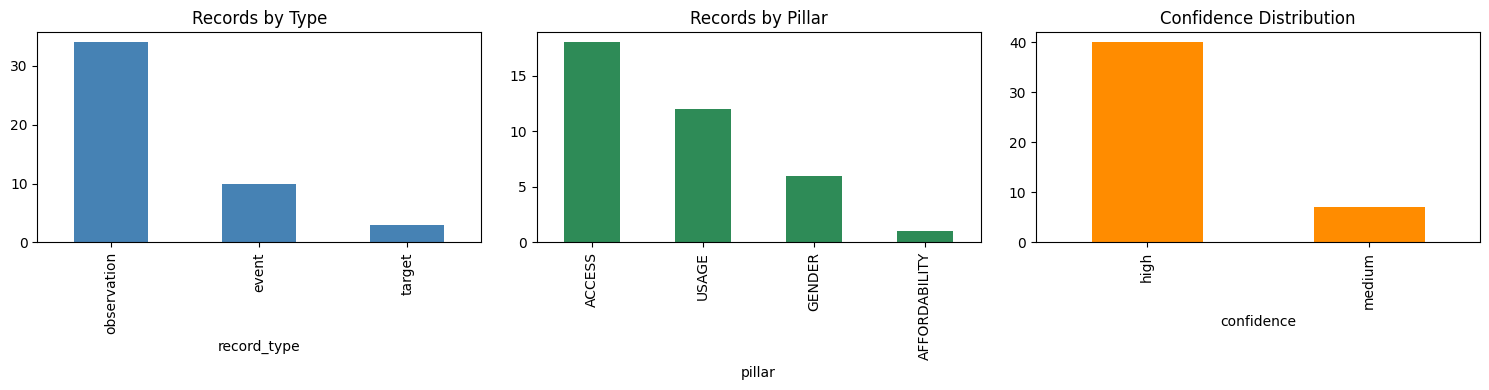

In [4]:
fig = plot_overview(main_df, save_path="../outputs/section1_overview.png")

Indicators with data in only 1 year (sparse coverage):
['ACC_AGENT_COUNT', 'ACC_MOBILE_PEN', 'ACC_SMARTPHONE_PEN', 'AFF_DATA_INCOME', 'GEN_GAP_MOBILE', 'GEN_GAP_SMARTPHONE', 'GEN_MM_SHARE', 'USG_ACTIVE_RATE', 'USG_AGENT_TXN_SHARE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_MPESA_ACTIVE', 'USG_MPESA_USERS', 'USG_P2P_VALUE', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE']


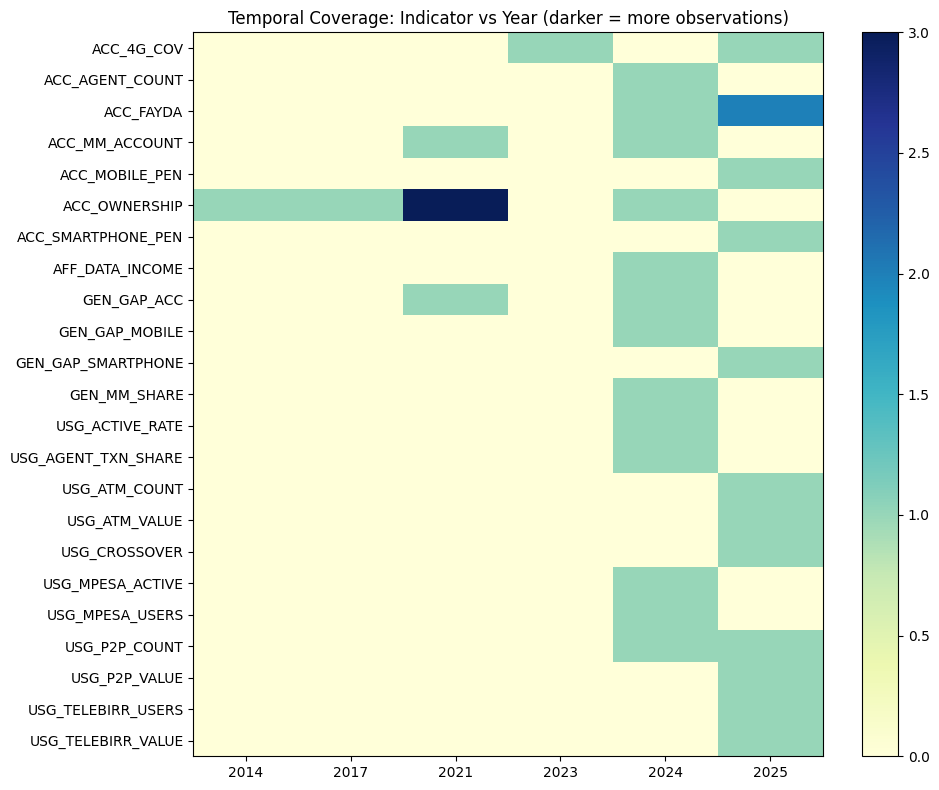

In [5]:
coverage = temporal_coverage(main_df)
sparse = sparse_indicators(coverage, max_years=1)
print("Indicators with data in only 1 year (sparse coverage):")
print(sparse)

fig = plot_temporal_coverage(coverage, save_path="../outputs/section1_coverage_heatmap.png")

**Data quality note:** with the exception of `ACC_OWNERSHIP` (4 distinct years: 2014, 2017, 2021, 2024), every indicator above has data in only 1-2 years. Any trend line other than Account Ownership is a two-point comparison, not a fitted trend — this limits how much statistical weight later sections can put on those single-year snapshots.

## Section 2: Access Analysis — Account Ownership

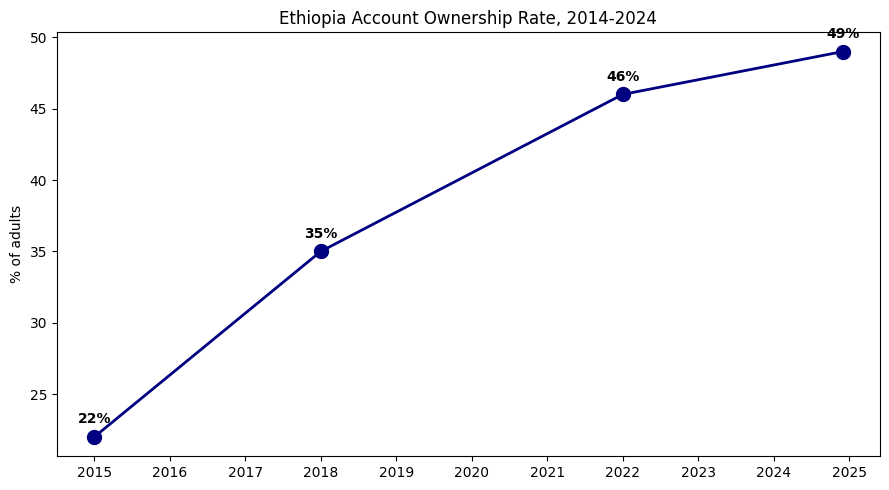

In [6]:
fig = plot_indicator_trend(
    main_df, "ACC_OWNERSHIP",
    title="Ethiopia Account Ownership Rate, 2014-2024",
    save_path="../outputs/section2_acc_ownership_trajectory.png"
)

In [7]:
growth = compute_growth_rates(main_df, "ACC_OWNERSHIP")
print(growth)

  fiscal_year  value_numeric  change_pp years_elapsed annualized_pp_per_year
0        2014           22.0        NaN           NaN                    NaN
1        2017           35.0       13.0             3               4.333333
2        2021           46.0       11.0             4                   2.75
3        2024           49.0        3.0             3                    1.0


**Insight:** annualized growth was +4.3pp/year (2014-17), +2.75pp/year (2017-21), and only +1.0pp/year (2021-24) — a real deceleration, not an artifact of uneven survey gaps.

In [8]:
gender_2021 = main_df[(main_df["indicator_code"] == "ACC_OWNERSHIP") & (main_df["fiscal_year"] == 2021)]
print("2021 Account Ownership by gender:")
print(gender_2021[["gender", "value_numeric"]])

gender_gap = main_df[main_df["indicator_code"] == "GEN_GAP_ACC"].sort_values("observation_date")
print("\nGender gap trend (Account Ownership):")
print(gender_gap[["observation_date", "value_numeric"]])

2021 Account Ownership by gender:
   gender  value_numeric
2     all           46.0
3    male           56.0
4  female           36.0

Gender gap trend (Account Ownership):
   observation_date  value_numeric
26       2021-12-31           20.0
27       2024-11-29           18.0


## Section 3: Usage Analysis — Registered vs. Active

In [9]:
# Note: Telebirr's registered user count and ACC_MM_ACCOUNT are in different
# units (raw count vs. % of adults), so a direct ratio would be meaningless.
# Presented side-by-side instead, with the mismatch itself noted as a finding.
telebirr_registered = main_df[main_df["indicator_code"] == "USG_TELEBIRR_USERS"]["value_numeric"].iloc[0]
mm_account_rate = main_df[main_df["indicator_code"] == "ACC_MM_ACCOUNT"].sort_values("observation_date")["value_numeric"].iloc[-1]
print(f"Telebirr registered users: {telebirr_registered:,.0f}")
print(f"Survey-measured Mobile Money Account Rate (2024): {mm_account_rate}% of adults")
print("These are not directly comparable (count vs. percentage) - the dataset "
      "does not provide a matching 'active Telebirr users' count the way it "
      "does for M-Pesa below. The scale mismatch alone (54.8M vs ~9.45% of "
      "adults) is itself informative.")

mpesa_gap = registered_vs_active_gap(main_df, "USG_MPESA_USERS", "USG_MPESA_ACTIVE")
print("\nM-Pesa registered vs. 90-day active (units match - both counts):")
print(mpesa_gap)

Telebirr registered users: 54,840,000
Survey-measured Mobile Money Account Rate (2024): 9.45% of adults
These are not directly comparable (count vs. percentage) - the dataset does not provide a matching 'active Telebirr users' count the way it does for M-Pesa below. The scale mismatch alone (54.8M vs ~9.45% of adults) is itself informative.

M-Pesa registered vs. 90-day active (units match - both counts):
{'registered_indicator': 'USG_MPESA_USERS', 'registered_value': np.float64(10800000.0), 'active_indicator': 'USG_MPESA_ACTIVE', 'active_value': np.float64(7100000.0), 'activity_rate_pct': np.float64(65.74074074074075)}


**Insight:** Telebirr and M-Pesa both show large gaps between registered sign-ups and survey-measured or activity-measured usage. This is likely the single biggest explanation for Account Ownership's stagnation despite tens of millions of new mobile money registrations.

## Section 4: Infrastructure and Enablers

In [10]:
infra = main_df[
    (main_df["record_type"] == "observation") &
    (main_df["indicator_code"].isin(["ACC_4G_COV", "ACC_FAYDA"]))
].sort_values("observation_date")
print(infra[["observation_date", "indicator", "value_numeric", "unit"]])

   observation_date                    indicator  value_numeric    unit
8        2023-06-30       4G Population Coverage           37.5       %
11       2024-08-15  Fayda Digital ID Enrollment      8000000.0  people
12       2025-02-28  Fayda Digital ID Enrollment     12000000.0  people
13       2025-05-15  Fayda Digital ID Enrollment     15000000.0  people
9        2025-06-30       4G Population Coverage           70.8       %


**Insight:** 4G population coverage nearly doubled (37.5% → 70.8%) between 2023 and 2025, while Account Ownership grew only 3pp in a comparable window. Infrastructure availability does not appear to be the current binding constraint on Access.

## Section 5: Event Timeline Overlay

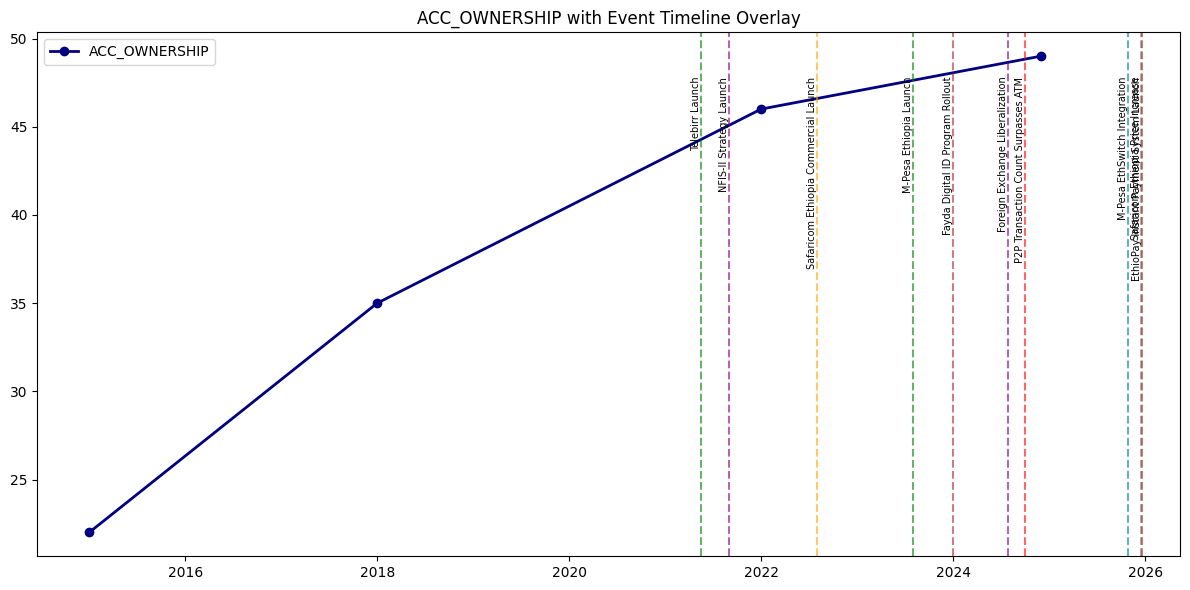

In [11]:
fig = plot_event_overlay(main_df, "ACC_OWNERSHIP", save_path="../outputs/section5_event_timeline.png")

In [12]:
gap_events = events_without_impact_links(main_df, impact_df)
print("Events with zero modeled impact_links:")
print(gap_events)

Events with zero modeled impact_links:
   record_id                            indicator   category observation_date
38  EVT_0006  P2P Transaction Count Surpasses ATM  milestone       2024-10-01


**Note:** the NFIS-II gap identified here was filled in Task 1's enrichment (`IMP_0015`). Any remaining gaps above are candidates for Task 3.

## Section 6: Correlation Analysis

In [13]:
corr = correlation_matrix(main_df, min_overlapping_years=2)
print("Correlation with ACC_OWNERSHIP (where at least 2 overlapping years exist):")
print(corr["ACC_OWNERSHIP"].dropna())

Correlation with ACC_OWNERSHIP (where at least 2 overlapping years exist):
ACC_MM_ACCOUNT    1.0
ACC_OWNERSHIP     1.0
GEN_GAP_ACC      -1.0
Name: ACC_OWNERSHIP, dtype: float64


**Important caveat:** most indicator pairs here only have 2 overlapping years. With just 2 points, any two monotonically increasing/decreasing series will show a correlation of ±1.0 regardless of whether the relationship is real. These figures are directional signals, not statistically validated correlations — this is stated explicitly rather than overstating the rigor the data supports.

## Section 7: Key Insights Summary

See `task2_key_insights.md` and `task2_data_quality_assessment.md` for the full write-up. Summary:

1. Account Ownership growth is genuinely decelerating (+4.3 → +2.75 → +1.0 pp/year).
2. The registered-vs-active gap likely explains the 2021-2024 stagnation.
3. Infrastructure has outpaced Access growth — not the current bottleneck.
4. The gender gap is narrowing slowly and unevenly (device-tier gap is wider than basic-phone gap).
5. Agent network scale doesn't equal utilization (17% of transaction volume from 216,000 registered agents).